# Producing SpatialFusion Representations

In [33]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding

# Standard library
import logging
import os
import warnings
import pathlib as pl

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import shapely.wkb
import tifffile
import timm
import torch
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms



In [34]:
# helper functions
import colorsys
from typing import Optional, Sequence, Mapping, Tuple, Dict, List

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex
import umap

def plot_embeddings(
    z1, z2, z_joint, labels, samples, label_title,
    palette="tab10", seed=42, max_cells=500_000
):

    rng = np.random.default_rng(seed)

    df = pd.DataFrame({"sample": samples, "label": labels}, index=z1.index)
    df["idx"] = np.arange(len(df))
    grouped = df.groupby("sample")

    # Determine how many cells per sample to keep
    total_samples = len(grouped)
    max_per_sample = max_cells // max(1, total_samples)

    # Subsample per sample group
    selected_indices = []
    for _, group in grouped:
        n = min(len(group), max_per_sample)
        selected_indices.extend(rng.choice(group["idx"].values, size=n, replace=False))

    # Subset everything
    z1 = z1.iloc[selected_indices]
    z2 = z2.iloc[selected_indices]
    z_joint = z_joint.iloc[selected_indices]
    labels = np.array(labels)[selected_indices]
    samples = np.array(samples)[selected_indices]

    # Apply PCA
    # pca = PCA(n_components=2)
    # explained_variance = []
    # z1_pca = pca.fit_transform(z1.values)
    # explained_variance.append(pca.explained_variance_ratio_)
    # z2_pca = pca.fit_transform(z2.values)
    # explained_variance.append(pca.explained_variance_ratio_)
    # z_joint_pca = pca.fit_transform(z_joint.values)
    # explained_variance.append(pca.explained_variance_ratio_)

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    z1_umap   = reducer.fit_transform(z1.values)
    print("done with z1")

    print(f"z1_pca (umap) shape: {z1_umap.shape}")
    print(f"z1_pca first 3 rows: {z1_umap[:3]}")
    print(f"Any NaN in umap output: {np.isnan(z1_umap).any()}")

    # check selected_indices
    print(f"Number of selected indices: {len(selected_indices)}")

    z2_umap   = reducer.fit_transform(z2.values)
    print("done with z2")
    z_joint_umap = reducer.fit_transform(z_joint.values)
    print('done with joint')

    # Shuffle for plot order
    #perm = rng.permutation(len(labels))
    #z1_pca = z1_pca[perm]
    #z2_pca = z2_pca[perm]
    #z_joint_pca = z_joint_pca[perm]
    #labels = labels[perm]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    point_size = 5  # keep a single source of truth for both scatter and legend markers

    def _strip_spines(ax):
        # Remove ALL spines (no plot borders)
        for spine in ax.spines.values():
            spine.set_visible(False)
        # No ticks and equal aspect
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

    def plot_scatter(ax, emb, title, show_legend=False):  # remove explained_variance param
        sns.scatterplot(
            x=emb[:, 0],
            y=emb[:, 1],
            hue=labels,
            palette=palette,
            s=point_size,
            ax=ax,
            linewidth=0,
            alpha=0.8,
            legend="full" if show_legend else False,
        )
        ax.set_title(title, fontsize=25)
        ax.set_xlabel("UMAP1")   # replace PC1 (x%)
        ax.set_ylabel("UMAP2")   # replace PC2 (x%)
        _strip_spines(ax)

        plot_scatter(axes[0], z1_umap,    "H&E (UMAP)")
        plot_scatter(axes[1], z2_umap,    "RNA (UMAP)")
        plot_scatter(axes[2], z_joint_umap, "Joint (UMAP)", show_legend=True)

    # Extract and remove subplot legend
    handles, labels_ = axes[2].get_legend_handles_labels()
    if axes[2].legend_ is not None:
        axes[2].legend_.remove()

    # Make legend marker sizes match the scatter point size
    # (handles from seaborn are PathCollections for the color items)
    for h in handles:
        if hasattr(h, "set_sizes"):
            h.set_sizes([point_size])  # one marker per legend entry

    # Add shared figure legend (text size follows rcParams; markers already matched)
    fig.legend(
        handles,
        labels_,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title=label_title,
        scatterpoints=1,     # one marker per legend entry
        markerscale=10,     # keep scale = 1 to respect set_sizes above
        frameon=False,       # optional: no border around the legend
        fontsize=16,        # control legend text size here
        title_fontsize=18,
    )

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(
        z1_umap[:, 0], z1_umap[:, 1],
        s=1, alpha=0.5, c='steelblue'
    )
    ax.set_title("Direct scatter test")
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_embeddings_simple(z1_pca, z2_pca, z_joint_pca, labels, title="Multimodal AE outputs"):
    
    # get unique cell types and assign colors
    unique_labels = list(dict.fromkeys(labels))  # preserves order
    cmap = plt.cm.get_cmap('tab20', len(unique_labels))
    color_dict = {ct: cmap(i) for i, ct in enumerate(unique_labels)}
    colors = [color_dict[l] for l in labels]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for ax, emb, title_panel in zip(
        axes,
        [z1_pca, z2_pca, z_joint_pca],
        ["H&E (UMAP)", "RNA (UMAP)", "Joint (UMAP)"]
    ):
        for ct in unique_labels:
            mask = np.array(labels) == ct
            ax.scatter(
                emb[mask, 0], emb[mask, 1],
                s=1, alpha=0.5, 
                color=color_dict[ct],
                linewidths=0,
                label=ct
            )
        ax.set_title(title_panel, fontsize=14)
        ax.axis('off')
    
    # shared legend
    patches = [mpatches.Patch(color=color_dict[ct], label=ct) for ct in unique_labels]
    fig.legend(
        handles=patches,
        loc='center right',
        bbox_to_anchor=(1.15, 0.5),
        fontsize=8,
        frameon=False,
        title=title,
        title_fontsize=10
    )
    
    plt.tight_layout()
    plt.savefig("umap_embeddings.png", dpi=150, bbox_inches='tight')
    plt.show()


NameError: name 'z1_pca' is not defined

In [35]:
# previously computed embeddings
output_dir = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/embeddings'
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI.parquet')
scgpt_df = pd.read_parquet(pl.Path(output_dir) / 'scGPT.parquet')

adata_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_train.h5ad"
adata = sc.read_h5ad(adata_path)

sample_name = "OVCA_Xenium_Full"

# read in wsi image (for visualization later)
source_image_path = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_full/ovca_he_image.ome.tif'

with tifffile.TiffFile(source_image_path) as tif:
    wsi = tif.series[0].asarray()

ae_inputs_by_sample = {
    sample_name: AEInputs(adata=adata, z_uni=uni_df, z_scgpt=scgpt_df),
}

In [36]:
from spatialfusion.utils.pkg_ckpt import resolve_pkg_ckpt
from spatialfusion.embed.embed import load_paired_ae, ae_from_arrays

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Resolve packaged pretrained checkpoints
ae_ckpt = resolve_pkg_ckpt("checkpoint_dir_ae/spatialfusion-multimodal-ae.pt")

# Infer dimensions
d1_dim, d2_dim = ae_inputs_by_sample[sample_name].z_uni.shape[1], ae_inputs_by_sample[sample_name].z_scgpt.shape[1]

# Load AE model
ae_model = load_paired_ae(ae_ckpt, d1_dim, d2_dim, latent_dim=64, device=device)

# Run AE embedding
z1_df, z2_df, z_joint_df = ae_from_arrays(
    ae_model,
    ae_inputs_by_sample[sample_name],
    device=device,
    combine_mode="average",  # or "concat", "z1", "z2",
    batch_size=None,  # optional, can be tuned based on dataset size and GPU memory, None automatically determines batch size based on input size and available memory
)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

Processing AE in batches: 100%|██████████| 73/73 [00:00<00:00, 94.90it/s]


In [38]:
# retrieve cell type and sample information for plotting
cell_type = adata.obs['cell_type'].ravel()
samples = [sample_name for _ in range(z1_df.shape[0])]

In [39]:
labels = cell_type
print(f"z1 shape: {z1_df.shape}")
print(f"z2 shape: {z2_df.shape}")
print(f"z_joint shape: {z_joint_df.shape}")
print(f"labels length: {len(labels)}")
print(f"samples length: {len(samples)}")
print(f"First few labels: {labels[:5]}")
print(f"z1 index first 3: {z1_df.index[:3].tolist()}")
print(f"labels index first 3 (if series): {labels.index[:3].tolist() if hasattr(labels, 'index') else 'not a series'}")

z1 shape: (360433, 64)
z2 shape: (360433, 64)
z_joint shape: (360433, 64)
labels length: 360433
samples length: 360433
First few labels: ['Proliferative Tumor Cells', 'Tumor Cells', 'Proliferative Tumor Cells', 'Proliferative Tumor Cells', 'Tumor Cells']
Categories (18, object): ['Ciliated Epithelial Cells', 'Fallopian Tube Epithelium', 'Inflammatory Tumor Cells', 'Macrophages', ..., 'Tumor Cells', 'Unassigned', 'Urothelial-like Cells', 'VEGFA+ Tumor Cells']
z1 index first 3: ['aaaaebmm-1', 'aaaafhpp-1', 'aaaahcem-1']
labels index first 3 (if series): not a series


/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


done with z1
z1_pca (umap) shape: (50000, 2)
z1_pca first 3 rows: [[13.695366   5.497086 ]
 [11.731257   7.2209144]
 [ 9.508449  15.024132 ]]
Any NaN in umap output: False
Number of selected indices: 50000
done with z2
done with joint


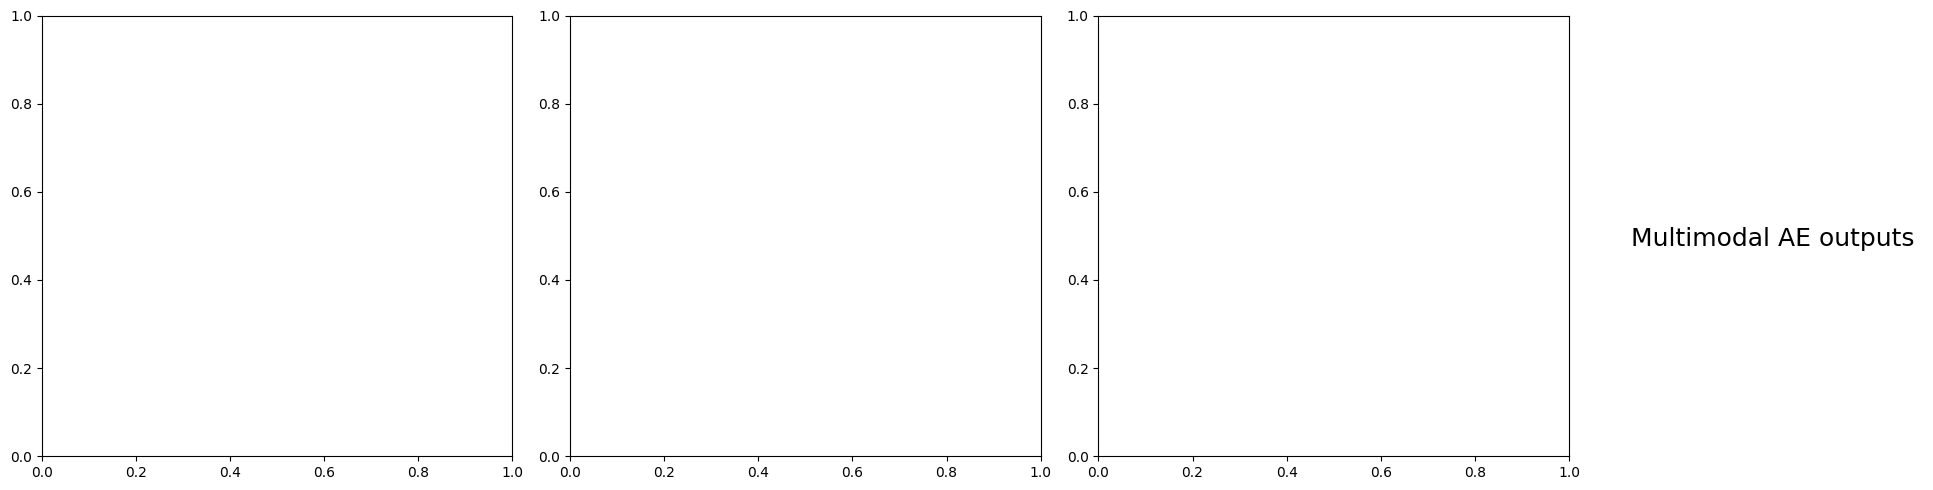

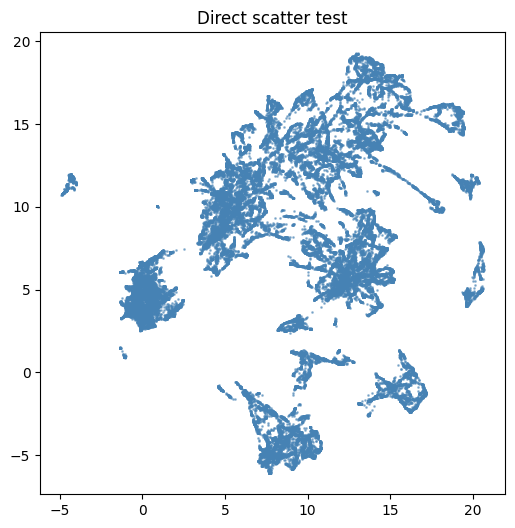

In [40]:
# Colored by broad cell types
plot_embeddings(
    z1_df, z2_df, z_joint_df, cell_type, samples, 'Multimodal AE outputs',
    palette="tab20", seed=42, max_cells=50_000
)


/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_2837170/4258875705.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))


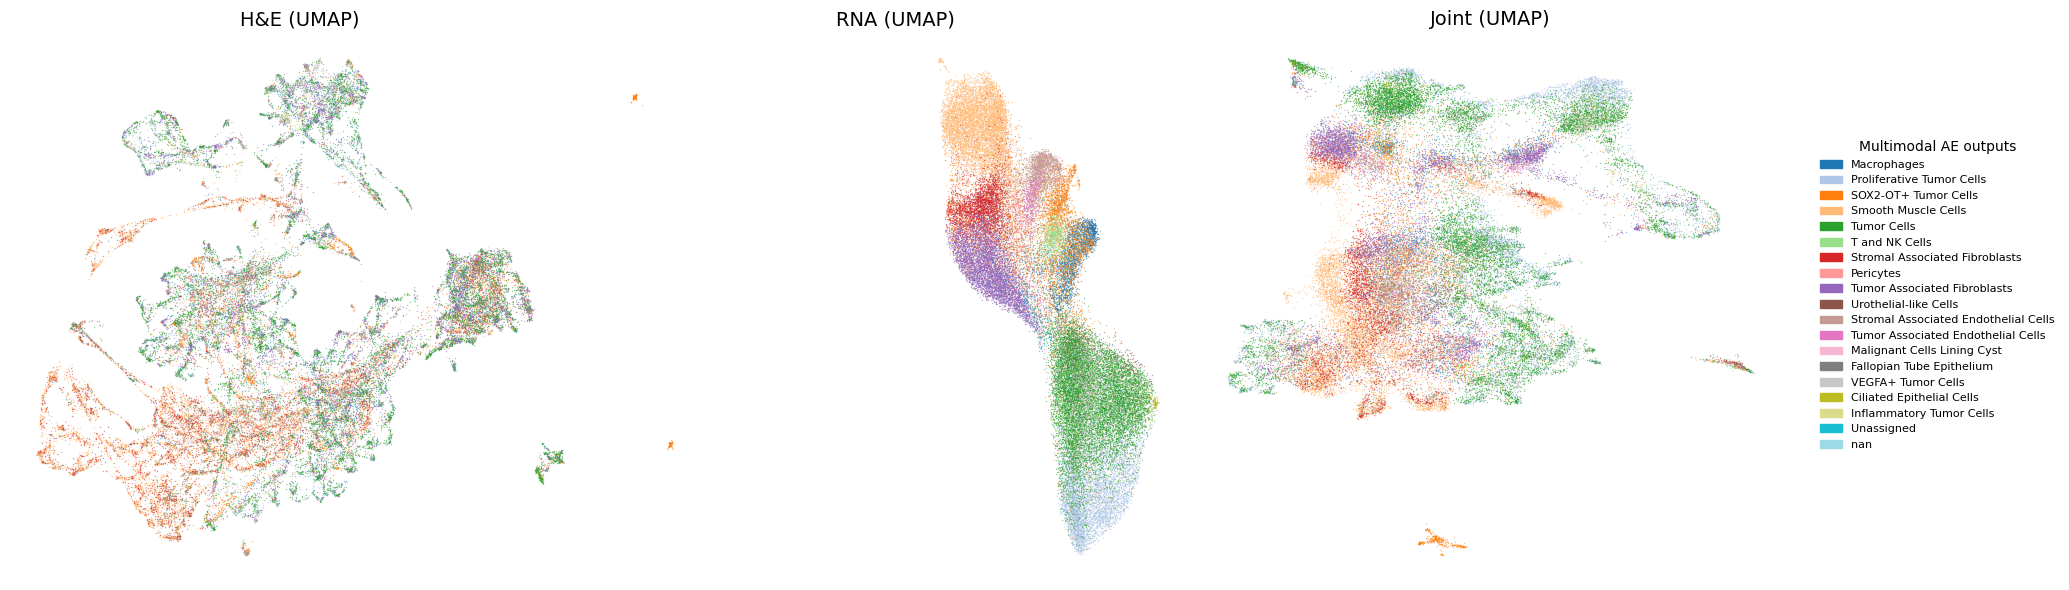

In [43]:
import numpy as np

# subsample 50k cells once, outside everything
rng = np.random.default_rng(42)
n_sample = 50_000
selected_indices = rng.choice(len(z1_df), size=n_sample, replace=False)

z1_sub     = z1_df.iloc[selected_indices]
z2_sub     = z2_df.iloc[selected_indices]
z_joint_sub = z_joint_df.iloc[selected_indices]
labels_sub = np.array(cell_type)[selected_indices]

# run UMAP on each
import umap
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=0.3)
z1_umap     = reducer.fit_transform(z1_sub.values)
z2_umap     = reducer.fit_transform(z2_sub.values)
z_joint_umap = reducer.fit_transform(z_joint_sub.values)

# plot
plot_embeddings_simple(z1_umap, z2_umap, z_joint_umap, labels_sub)